"""
bermuda 중고차 가격 예측 — Quantile Regression Pipeline
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Raw data  : bermuda_data_v2.csv
인코딩    : 모델 컬럼 → CV Target Encoding (5-Fold, smooth_k=10)
Target    : 현재가격_만원 (log1p 변환 후 학습)
분할      : Train 70% / Val 10% / Test 20%
              └ Val → early stopping 전용 (test 누수 차단)
모델 5종  : Linear QR / LightGBM / XGBoost / GradientBoosting / RandomForest
분위수    : Q10 (하한) / Q50 (중앙 권장가) / Q90 (상한)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""


[STEP 1] 데이터 로드
로드 완료: 13,431행 × 36컬럼
가격 범위: 140 ~ 9,998만원  |  중앙값: 1,650만원

[STEP 2] Train / Val / Test 분리
Train : 9,401행  (70.0%)
Val   : 1,343행   (10.0%)
Test  : 2,687행  (20.0%)

[STEP 3] 이상치 제거 (Train 전용)
  주행거리_km        : 4건 제거
  차량연령           : 3건 제거
  사고강도점수         : 31건 제거
  현재가격_만원        : 16건 제거
이상치 제거 결과: 9,401 → 9,347행 (총 54건 제거)

[STEP 4] CV Target Encoding (모델 컬럼)
CV TE 상관관계
  Train (OOF) : 0.7605
  Val         : 0.7519
  Test        : 0.7636
  → Val/Test가 Train보다 다소 높으면 정상 (OOF의 보수적 특성)

[STEP 5] Feature / Target 준비
Feature 수    : 34개
Feature 목록  : ['주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '연료_수소', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '변속기_오토계열', '차급_SUV계열', '차급_세단계열', '모델_CV_TE']
y 범위 (log)  : 4.949 ~

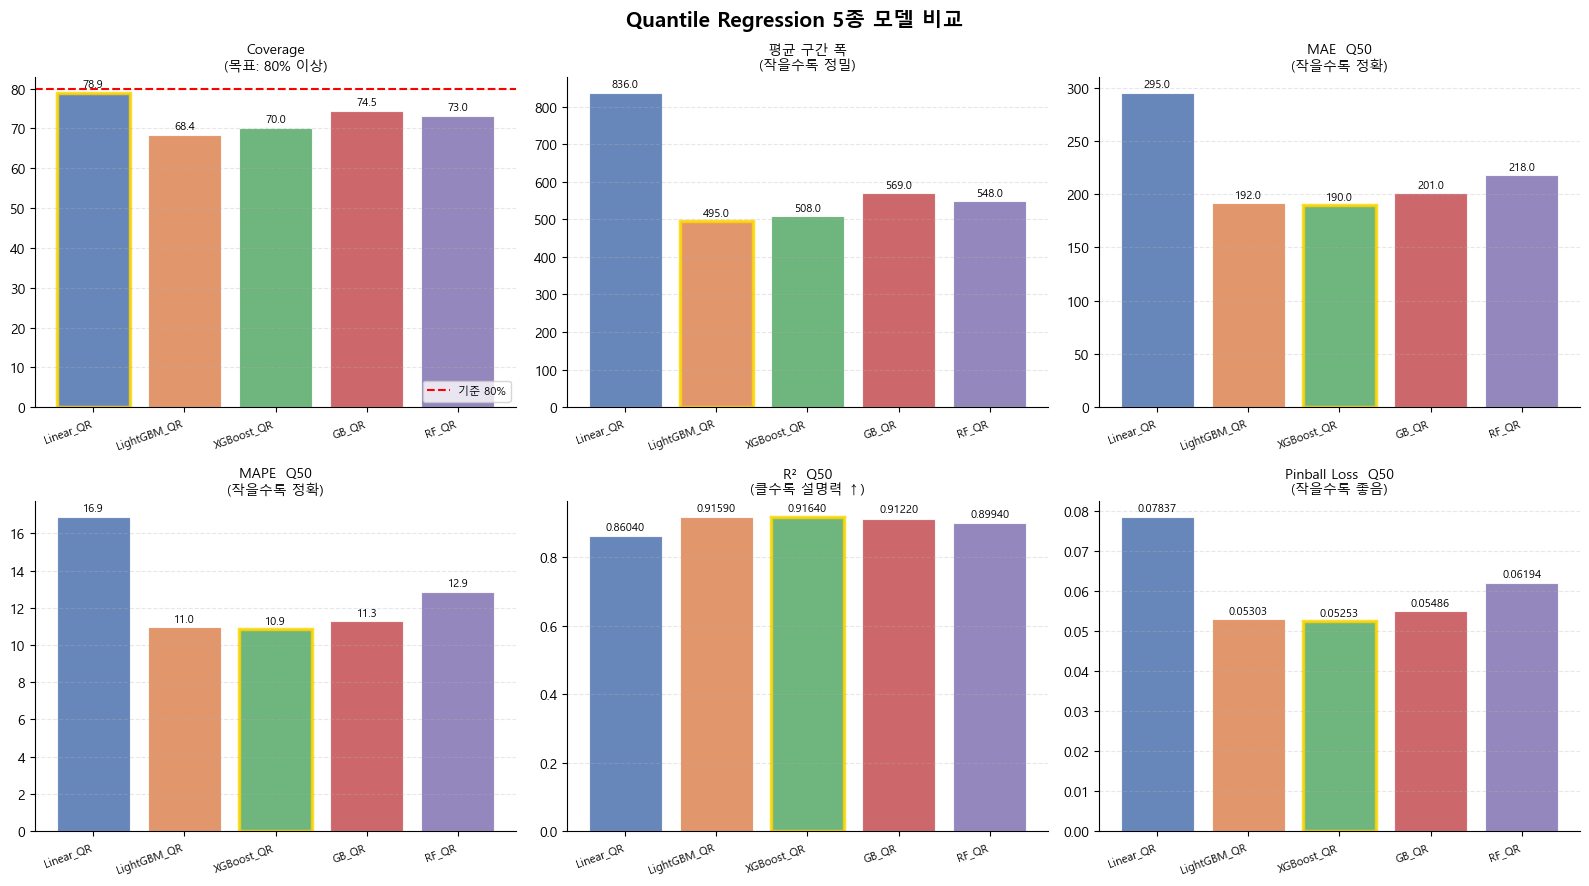

저장 완료: C:\Users\Admin\hipython\ml\bermuda.project\data\quantile_model_comparison.png

[STEP 10] 결과 저장
저장 완료: C:\Users\Admin\hipython\ml\bermuda.project\data\quantile_results.csv

✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ 
전체 파이프라인 완료
✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ 


In [4]:
import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')
except AttributeError:
    pass

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import QuantileRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

import lightgbm as lgb
import xgboost as xgb


# ══════════════════════════════════════════════════════════════════
# 0. 설정
# ══════════════════════════════════════════════════════════════════

DATA_PATH   = r'C:\Users\Admin\hipython\ml\bermuda.project\data\bermuda_data_v2.csv'
OUT_DIR     = r'C:\Users\Admin\hipython\ml\bermuda.project\data'

TARGET      = '현재가격_만원'
QUANTILES   = [0.10, 0.50, 0.90]
Q_LABELS    = ['q10', 'q50', 'q90']
RANDOM_SEED = 42
IQR_MULT    = 3.0
N_SPLITS    = 5
SMOOTH_K    = 10


# ══════════════════════════════════════════════════════════════════
# 1. 데이터 로드
# ══════════════════════════════════════════════════════════════════

print('=' * 60)
print('[STEP 1] 데이터 로드')
print('=' * 60)

df = pd.read_csv(DATA_PATH, encoding='utf-8')
print(f'로드 완료: {df.shape[0]:,}행 × {df.shape[1]}컬럼')
print(f'가격 범위: {df[TARGET].min():,} ~ {df[TARGET].max():,}만원  |  중앙값: {df[TARGET].median():,.0f}만원')


# ══════════════════════════════════════════════════════════════════
# 2. Train / Val / Test 분리 (70 / 10 / 20)
#    - Val : early stopping 전용 (test 누수 차단)
#    - Test: 최종 성능 평가 전용
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 2] Train / Val / Test 분리')
print('=' * 60)

trainval_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_SEED)
train_df, val_df     = train_test_split(trainval_df, test_size=0.125, random_state=RANDOM_SEED)
# 0.125 of 0.80 = 0.10 of total → 70 / 10 / 20

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):,}행  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,}행   ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):,}행  ({len(test_df)/len(df)*100:.1f}%)')


# ══════════════════════════════════════════════════════════════════
# 3. 이상치 제거 (Train 전용, IQR × 3.0)
#    - 수소차 배기량_cc=0 예외 처리
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 3] 이상치 제거 (Train 전용)')
print('=' * 60)

num_cols = ['주행거리_km', '배기량_cc', '차량연령', '사고강도점수', TARGET]
before = len(train_df)

for col in num_cols:
    if col == '배기량_cc':
        # 수소차는 배기량_cc=0 정상값 → 이상치 계산에서 제외
        mask_exempt = (train_df['연료_수소'] == 1)
        sub = train_df.loc[~mask_exempt, col]
        q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
        iqr = q3 - q1
        out_mask = (~mask_exempt) & (
            (train_df[col] < q1 - IQR_MULT * iqr) |
            (train_df[col] > q3 + IQR_MULT * iqr)
        )
    else:
        q1, q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
        iqr = q3 - q1
        out_mask = (
            (train_df[col] < q1 - IQR_MULT * iqr) |
            (train_df[col] > q3 + IQR_MULT * iqr)
        )
    removed = out_mask.sum()
    if removed > 0:
        print(f'  {col:<15}: {removed}건 제거')
    train_df = train_df[~out_mask].reset_index(drop=True)

after = len(train_df)
print(f'이상치 제거 결과: {before:,} → {after:,}행 (총 {before - after}건 제거)')


# ══════════════════════════════════════════════════════════════════
# 4. CV Target Encoding (모델 컬럼)
#    - Train : 5-Fold OOF 방식 (자기 자신 제외 → 누수 차단)
#    - Val   : 전체 Train 기준 인코딩
#    - Test  : 전체 Train 기준 인코딩
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 4] CV Target Encoding (모델 컬럼)')
print('=' * 60)

def cv_target_encoding(train_df, apply_dfs, col, target,
                       n_splits=5, smooth_k=10, random_state=42):
    """
    Parameters
    ----------
    train_df   : 인코딩 기준이 되는 Train DataFrame
    apply_dfs  : [val_df, test_df] 리스트 — Train 기준으로 인코딩만 적용
    col        : 인코딩 컬럼 ('모델')
    target     : 타겟 컬럼 ('현재가격_만원')
    smooth_k   : 소표본 모델을 전체 평균으로 당기는 강도
                 (건수=smooth_k 일 때 자체평균 50% + 전체평균 50% 블렌딩)

    Returns
    -------
    train_encoded       : Train OOF 인코딩 배열
    apply_encoded_list  : [val_encoded, test_encoded]
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    global_mean   = train_df[target].mean()
    train_encoded = np.zeros(len(train_df))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df)):
        tr_fold  = train_df.iloc[tr_idx]
        val_fold = train_df.iloc[val_idx]

        fold_mean  = tr_fold.groupby(col)[target].mean()
        fold_count = tr_fold.groupby(col)[target].count()
        # Bayesian Smoothing: 건수 적을수록 전체평균으로 당김
        smoothed = (fold_count * fold_mean + smooth_k * global_mean) / (fold_count + smooth_k)

        train_encoded[val_idx] = val_fold[col].map(smoothed).fillna(global_mean).values

    # Val / Test: 전체 Train 기준 (test 정보 미포함 → 누수 없음)
    final_mean     = train_df.groupby(col)[target].mean()
    final_count    = train_df.groupby(col)[target].count()
    final_smoothed = (final_count * final_mean + smooth_k * global_mean) / (final_count + smooth_k)

    apply_encoded_list = [
        df_[col].map(final_smoothed).fillna(global_mean).values
        for df_ in apply_dfs
    ]

    return train_encoded, apply_encoded_list


train_te, (val_te, test_te) = cv_target_encoding(
    train_df, [val_df, test_df],
    col='모델', target=TARGET,
    n_splits=N_SPLITS, smooth_k=SMOOTH_K,
)

train_df['모델_CV_TE'] = train_te
val_df['모델_CV_TE']   = val_te
test_df['모델_CV_TE']  = test_te

corr_train = train_df['모델_CV_TE'].corr(train_df[TARGET])
corr_val   = val_df['모델_CV_TE'].corr(val_df[TARGET])
corr_test  = test_df['모델_CV_TE'].corr(test_df[TARGET])

print(f'CV TE 상관관계')
print(f'  Train (OOF) : {corr_train:.4f}')
print(f'  Val         : {corr_val:.4f}')
print(f'  Test        : {corr_test:.4f}')
print(f'  → Val/Test가 Train보다 다소 높으면 정상 (OOF의 보수적 특성)')


# ══════════════════════════════════════════════════════════════════
# 5. Feature / Target 준비
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 5] Feature / Target 준비')
print('=' * 60)

DROP_COLS    = ['매물ID', '모델']    # 모델_CV_TE로 대체됨
feature_cols = [c for c in train_df.columns if c not in DROP_COLS + [TARGET]]

X_train = train_df[feature_cols].values
X_val   = val_df[feature_cols].values
X_test  = test_df[feature_cols].values

y_train_raw = train_df[TARGET].values
y_val_raw   = val_df[TARGET].values
y_test_raw  = test_df[TARGET].values

# Log1p 변환 (가격 분포의 오른쪽 꼬리 완화)
y_train = np.log1p(y_train_raw)
y_val   = np.log1p(y_val_raw)
y_test  = np.log1p(y_test_raw)

# StandardScaler — Linear QR 전용
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_val_sc      = scaler.transform(X_val)
X_test_sc     = scaler.transform(X_test)

print(f'Feature 수    : {len(feature_cols)}개')
print(f'Feature 목록  : {feature_cols}')
print(f'y 범위 (log)  : {y_train.min():.3f} ~ {y_train.max():.3f}')
print(f'y 범위 (원본) : {y_train_raw.min():,} ~ {y_train_raw.max():,}만원')


# ══════════════════════════════════════════════════════════════════
# 6. 평가 함수
# ══════════════════════════════════════════════════════════════════

def pinball_loss(y_true, y_pred, q):
    """Pinball (Quantile) Loss — log scale 기준"""
    err = y_true - y_pred
    return float(np.mean(np.where(err >= 0, q * err, (q - 1) * err)))


def evaluate_quantile(name, preds_dict, y_true_raw):
    """
    Parameters
    ----------
    name       : 모델 이름 (str)
    preds_dict : {'q10': array, 'q50': array, 'q90': array}  ← 원래 스케일(만원)
    y_true_raw : 실제 가격 배열 (원래 스케일)

    Returns
    -------
    dict : 전체 평가 지표
    """
    q10, q50, q90 = preds_dict['q10'], preds_dict['q50'], preds_dict['q90']

    # ── Interval 지표 ──────────────────────────────────────────
    in_range  = (y_true_raw >= q10) & (y_true_raw <= q90)
    coverage  = in_range.mean() * 100
    width_avg = float((q90 - q10).mean())
    width_med = float(np.median(q90 - q10))

    # ── Q50 회귀 지표 ─────────────────────────────────────────
    mae  = float(np.mean(np.abs(y_true_raw - q50)))
    mdae = float(np.median(np.abs(y_true_raw - q50)))
    rmse = float(np.sqrt(np.mean((y_true_raw - q50) ** 2)))
    r2   = float(1 - np.sum((y_true_raw - q50) ** 2) / np.sum((y_true_raw - y_true_raw.mean()) ** 2))
    mape = float(np.mean(np.abs((y_true_raw - q50) / y_true_raw)) * 100)
    acc10 = float(np.mean(np.abs((y_true_raw - q50) / y_true_raw) <= 0.10) * 100)
    acc20 = float(np.mean(np.abs((y_true_raw - q50) / y_true_raw) <= 0.20) * 100)

    # ── Pinball Loss (log scale) ──────────────────────────────
    y_log  = np.log1p(y_true_raw)
    pb10   = pinball_loss(y_log, np.log1p(np.clip(q10, 1e-6, None)), 0.10)
    pb50   = pinball_loss(y_log, np.log1p(np.clip(q50, 1e-6, None)), 0.50)
    pb90   = pinball_loss(y_log, np.log1p(np.clip(q90, 1e-6, None)), 0.90)

    result = {
        'Model'       : name,
        'Coverage%'   : round(coverage,  2),
        'Width_avg'   : round(width_avg, 0),
        'Width_med'   : round(width_med, 0),
        'MAE_q50'     : round(mae,  0),
        'MdAE_q50'    : round(mdae, 0),
        'RMSE_q50'    : round(rmse, 0),
        'R2_q50'      : round(r2,   4),
        'MAPE_q50%'   : round(mape, 2),
        '±10%_q50'    : round(acc10, 2),
        '±20%_q50'    : round(acc20, 2),
        'Pinball_q10' : round(pb10, 5),
        'Pinball_q50' : round(pb50, 5),
        'Pinball_q90' : round(pb90, 5),
    }

    # 콘솔 출력
    print(f'\n  ┌─ [{name}]')
    print(f'  │  Coverage   : {coverage:.1f}%  (목표 ≥ 80%)')
    print(f'  │  Width      : 평균 {width_avg:.0f}만원 / 중앙 {width_med:.0f}만원')
    print(f'  │  Q50 MAE    : {mae:.0f}만원  MdAE: {mdae:.0f}만원  RMSE: {rmse:.0f}만원')
    print(f'  │  Q50 R²     : {r2:.4f}   MAPE: {mape:.2f}%')
    print(f'  │  ±10%/±20%  : {acc10:.1f}% / {acc20:.1f}%')
    print(f'  └─ Pinball    : Q10={pb10:.5f}  Q50={pb50:.5f}  Q90={pb90:.5f}')

    return result


results_q = []


# ══════════════════════════════════════════════════════════════════
# 7-A. Linear Quantile Regression
#      - sklearn QuantileRegressor, alpha=0.0 (정규화 없음)
#      - 선형 모델 → StandardScaler 적용 데이터 사용
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 1/5] Linear Quantile Regression')
print('=' * 60)

preds_lqr = {}
for q, label in zip(QUANTILES, Q_LABELS):
    model = QuantileRegressor(quantile=q, alpha=0.0, solver='highs')
    model.fit(X_train_sc, y_train)
    pred_log = model.predict(X_test_sc)
    preds_lqr[label] = np.expm1(pred_log)
    print(f'  Q{int(q*100):2d} 완료')

# Quantile Crossing 보정 (Q10 ≤ Q50 ≤ Q90 보장)
preds_lqr['q10'] = np.minimum(preds_lqr['q10'], preds_lqr['q50'])
preds_lqr['q90'] = np.maximum(preds_lqr['q90'], preds_lqr['q50'])

results_q.append(evaluate_quantile('Linear_QR', preds_lqr, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-B. LightGBM Quantile
#      - early stopping: Val 세트 기준
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 2/5] LightGBM Quantile')
print('=' * 60)

lgb_params_base = dict(
    n_estimators     = 3000,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    random_state     = RANDOM_SEED,
    n_jobs           = -1,
    verbose          = -1,
)

preds_lgb = {}
for q, label in zip(QUANTILES, Q_LABELS):
    params = {**lgb_params_base, 'objective': 'quantile', 'alpha': q}
    model  = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set  = [(X_val, y_val)],
        callbacks = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(0)],
    )
    preds_lgb[label] = np.expm1(model.predict(X_test))
    print(f'  Q{int(q*100):2d} 완료  (best iter: {model.best_iteration_:,})')

preds_lgb['q10'] = np.minimum(preds_lgb['q10'], preds_lgb['q50'])
preds_lgb['q90'] = np.maximum(preds_lgb['q90'], preds_lgb['q50'])

results_q.append(evaluate_quantile('LightGBM_QR', preds_lgb, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-C. XGBoost Quantile
#      - objective='reg:quantileerror' (XGBoost ≥ 2.0 필요)
#      - early stopping: Val 세트 기준
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 3/5] XGBoost Quantile')
print('=' * 60)

xgb_params_base = dict(
    n_estimators         = 3000,
    learning_rate        = 0.05,
    max_depth            = 6,
    subsample            = 0.8,
    colsample_bytree     = 0.8,
    reg_alpha            = 0.1,
    reg_lambda           = 0.1,
    early_stopping_rounds= 50,
    tree_method          = 'hist',
    random_state         = RANDOM_SEED,
    n_jobs               = -1,
)

preds_xgb = {}
for q, label in zip(QUANTILES, Q_LABELS):
    params = {**xgb_params_base, 'objective': 'reg:quantileerror', 'quantile_alpha': q}
    model  = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)], verbose=False)
    preds_xgb[label] = np.expm1(model.predict(X_test))
    print(f'  Q{int(q*100):2d} 완료  (best iter: {model.best_iteration:,})')

preds_xgb['q10'] = np.minimum(preds_xgb['q10'], preds_xgb['q50'])
preds_xgb['q90'] = np.maximum(preds_xgb['q90'], preds_xgb['q50'])

results_q.append(evaluate_quantile('XGBoost_QR', preds_xgb, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-D. GradientBoosting Quantile
#      - sklearn GradientBoostingRegressor (early stopping 미지원)
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 4/5] GradientBoosting Quantile')
print('=' * 60)

gb_params_base = dict(
    n_estimators  = 500,
    learning_rate = 0.05,
    max_depth     = 5,
    subsample     = 0.8,
    random_state  = RANDOM_SEED,
)

preds_gb = {}
for q, label in zip(QUANTILES, Q_LABELS):
    params = {**gb_params_base, 'loss': 'quantile', 'alpha': q}
    model  = GradientBoostingRegressor(**params)
    model.fit(X_train, y_train)
    preds_gb[label] = np.expm1(model.predict(X_test))
    print(f'  Q{int(q*100):2d} 완료')

preds_gb['q10'] = np.minimum(preds_gb['q10'], preds_gb['q50'])
preds_gb['q90'] = np.maximum(preds_gb['q90'], preds_gb['q50'])

results_q.append(evaluate_quantile('GB_QR', preds_gb, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-E. Random Forest Quantile
#      - 각 트리의 예측 분포에서 np.quantile로 직접 계산
#      - quantile_forest 패키지 없이 구현
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 5/5] Random Forest Quantile')
print('=' * 60)

rf_model = RandomForestRegressor(
    n_estimators   = 300,
    max_depth      = None,
    min_samples_leaf = 5,
    random_state   = RANDOM_SEED,
    n_jobs         = -1,
)
rf_model.fit(X_train, y_train)

# 각 트리 예측값 수집 → shape: (n_trees, n_test_samples)
tree_preds_log = np.array([tree.predict(X_test) for tree in rf_model.estimators_])

preds_rf = {}
for q, label in zip(QUANTILES, Q_LABELS):
    pred_log      = np.quantile(tree_preds_log, q, axis=0)
    preds_rf[label] = np.expm1(pred_log)

preds_rf['q10'] = np.minimum(preds_rf['q10'], preds_rf['q50'])
preds_rf['q90'] = np.maximum(preds_rf['q90'], preds_rf['q50'])

print('  완료')
results_q.append(evaluate_quantile('RF_QR', preds_rf, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 8. 결과 비교 테이블 + 지표별 최우수 모델
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 8] 전체 결과 비교')
print('=' * 60)

results_df = pd.DataFrame(results_q).set_index('Model')
print(results_df.to_string())

# 지표별 최우수 모델 (방향성 명시)
best_spec = {
    'Coverage%'  : ('max', '높을수록 좋음'),
    'Width_avg'  : ('min', '작을수록 좋음'),
    'MAE_q50'    : ('min', '작을수록 좋음'),
    'MAPE_q50%'  : ('min', '작을수록 좋음'),
    'R2_q50'     : ('max', '클수록 좋음'),
    'Pinball_q50': ('min', '작을수록 좋음'),
}

print('\n[지표별 Best Model]')
print(f'  {"지표":<15}  {"Best Model":<20}  {"값":>10}  비고')
print('  ' + '-' * 60)
for metric, (direction, note) in best_spec.items():
    best_model = results_df[metric].idxmax() if direction == 'max' else results_df[metric].idxmin()
    best_val   = results_df.loc[best_model, metric]
    print(f'  {metric:<15}  {best_model:<20}  {best_val:>10}  {note}')


# ══════════════════════════════════════════════════════════════════
# 9. 시각화 — 6개 지표 Bar Chart
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 9] 시각화')
print('=' * 60)

MODELS   = results_df.index.tolist()
COLORS   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

metrics_plot = [
    # (컬럼명,        제목,                       threshold, 높을수록좋음)
    ('Coverage%',    'Coverage\n(목표: 80% 이상)',    80,   True ),
    ('Width_avg',    '평균 구간 폭\n(작을수록 정밀)',  None, False),
    ('MAE_q50',      'MAE  Q50\n(작을수록 정확)',      None, False),
    ('MAPE_q50%',    'MAPE  Q50\n(작을수록 정확)',     None, False),
    ('R2_q50',       'R²  Q50\n(클수록 설명력 ↑)',    None, True ),
    ('Pinball_q50',  'Pinball Loss  Q50\n(작을수록 좋음)', None, False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Quantile Regression 5종 모델 비교', fontsize=15, fontweight='bold')

for ax, (metric, title, threshold, higher_better) in zip(axes.flatten(), metrics_plot):
    vals     = results_df[metric].values
    best_idx = int(np.argmax(vals)) if higher_better else int(np.argmin(vals))

    bars = ax.bar(MODELS, vals, color=COLORS, alpha=0.85, edgecolor='white', linewidth=0.8)

    # 최우수 모델 테두리 강조
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

    # 기준선 (Coverage 80%)
    if threshold is not None:
        ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
                   label=f'기준 {threshold}%')
        ax.legend(fontsize=8, loc='lower right')

    # 값 레이블
    for bar, val in zip(bars, vals):
        fmt = f'{val:.1f}' if abs(val) >= 1 else f'{val:.5f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                fmt, ha='center', va='bottom', fontsize=8)

    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xticklabels(MODELS, rotation=20, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out_img = f'{OUT_DIR}\\quantile_model_comparison.png'
plt.savefig(out_img, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_img}')


# ══════════════════════════════════════════════════════════════════
# 10. 결과 CSV 저장
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 10] 결과 저장')
print('=' * 60)

out_csv = f'{OUT_DIR}\\quantile_results.csv'
results_df.to_csv(out_csv, encoding='utf-8-sig')
print(f'저장 완료: {out_csv}')

print('\n' + '✅ ' * 20)
print('전체 파이프라인 완료')
print('✅ ' * 20)


"""
bermuda 중고차 가격 예측 — Quantile Regression Pipeline
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Raw data  : bermuda_data_v2.csv
인코딩    : 모델 컬럼 → CV Target Encoding (5-Fold, smooth_k=10)
Target    : 현재가격_만원 (log1p 변환 후 학습)
분할      : Train 70% / Val 10% / Test 20%
              └ Val → early stopping 및 Conformal 보정 전용 (test 누수 차단)
모델 6종  : Linear QR / LightGBM / XGBoost / GradientBoosting / RandomForest
            + Conformal Prediction (LightGBM RMSE + Val 잔차 보정)
분위수    : Q10 (하한) / Q50 (중앙 권장가) / Q90 (상한)

[Conformal Prediction 원리]
  ① LightGBM RMSE 점 예측 모델 훈련
  ② Val 세트 잔차(signed) 분포 계산
  ③ 80% Coverage 목표 → α=0.20
     Q_lo = ⌈(n+1)×0.10⌉/n 분위수  ← 하한 보정량
     Q_hi = ⌈(n+1)×0.90⌉/n 분위수  ← 상한 보정량
  ④ 구간 = [ŷ + Q_lo , ŷ + Q_hi]   (log scale → expm1 역변환)
  → 수학적으로 Coverage ≥ 80% 보장 (Split Conformal Guarantee)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

[STEP 1] 데이터 로드
로드 완료: 13,431행 × 36컬럼
가격 범위: 140 ~ 9,998만원  |  중앙값: 1,650만원

[STEP 2] Train / Val / Test 분리
Train : 9,401행  (70.0%)
Val   : 1,343행   (10.0%)
Test  : 2,687행  (20.0%)

[STEP 3] 이상치 제거 (Train 전용)
  주행거리_km        : 4건 제거
  차량연령           : 3건 제거
  사고강도점수         : 31건 제거
  현재가격_만원        : 16건 제거
이상치 제거 결과: 9,401 → 9,347행 (총 54건 제거)

[STEP 4] CV Target Encoding (모델 컬럼)
CV TE 상관관계
  Train (OOF) : 0.7605
  Val         : 0.7519
  Test        : 0.7636
  → Val/Test가 Train보다 다소 높으면 정상 (OOF의 보수적 특성)

[STEP 5] Feature / Target 준비
Feature 수    : 34개
Feature 목록  : ['주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '연료_수소', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '변속기_오토계열', '차급_SUV계열', '차급_세단계열', '모델_CV_TE']
y 범위 (log)  : 4.949 ~

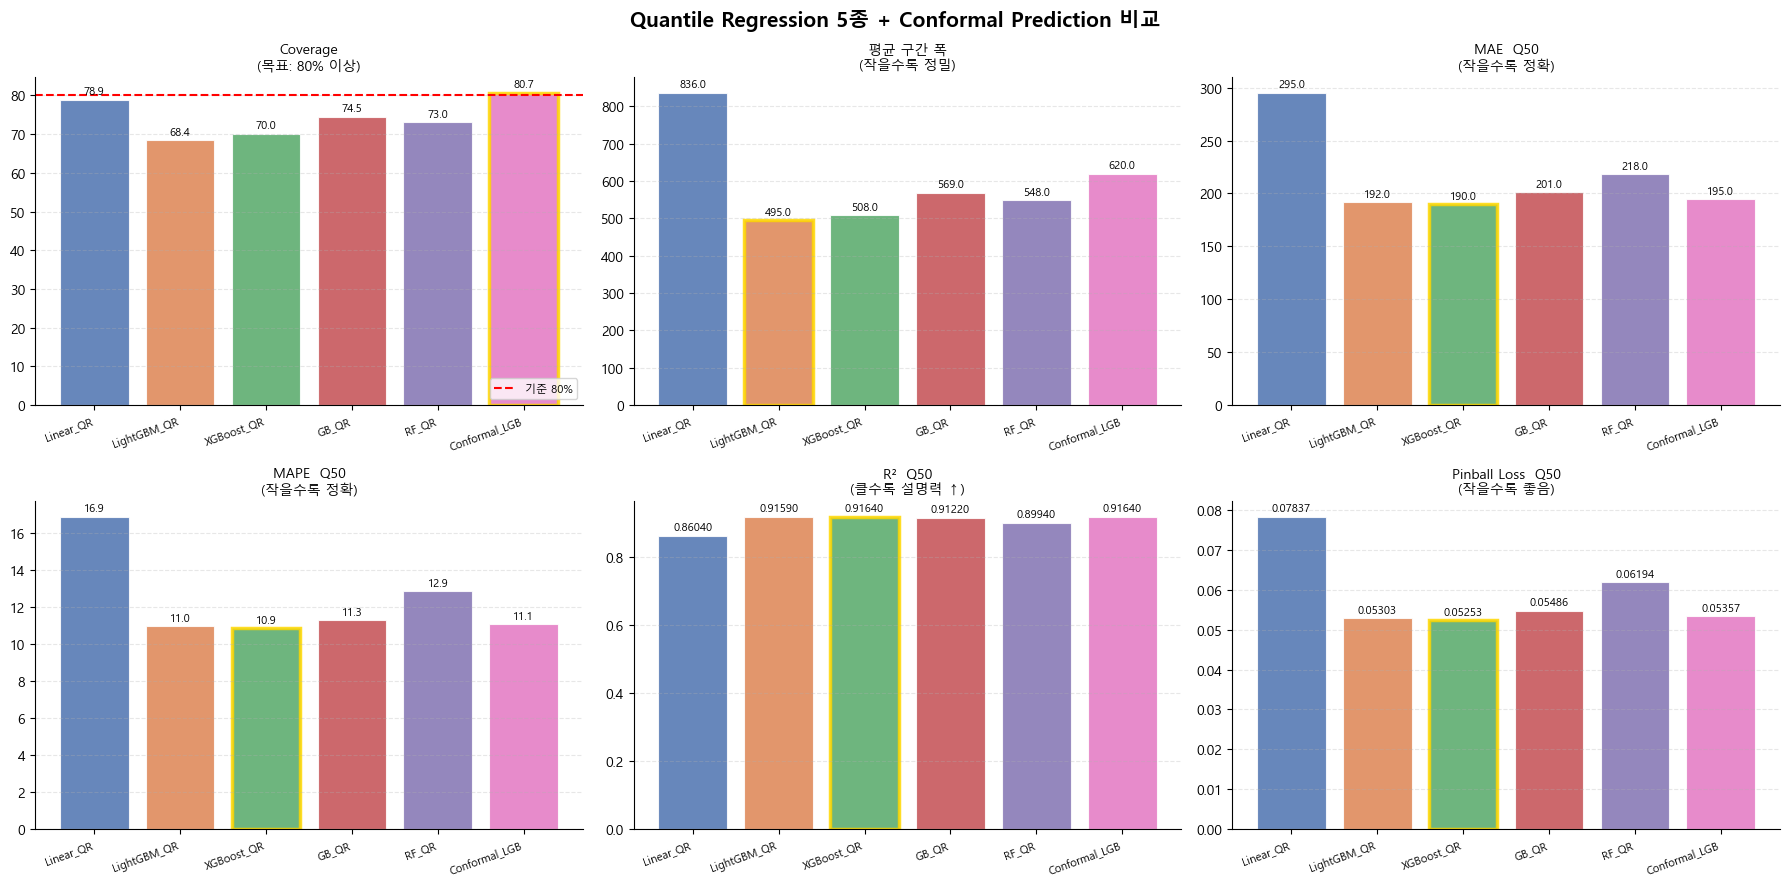

저장 완료: C:\Users\Admin\hipython\ml\bermuda.project\data\quantile_conformal_comparison.png

[STEP 10] 결과 저장
저장 완료: C:\Users\Admin\hipython\ml\bermuda.project\data\quantile_conformal_results.csv

✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ 
전체 파이프라인 완료
✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ ✅ 


In [5]:
import sys
# Jupyter 환경은 OutStream 객체라 reconfigure 미지원 → 예외 처리
try:
    sys.stdout.reconfigure(encoding='utf-8')
except AttributeError:
    pass

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import QuantileRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

import lightgbm as lgb
import xgboost as xgb


# ══════════════════════════════════════════════════════════════════
# 0. 설정
# ══════════════════════════════════════════════════════════════════

DATA_PATH   = r'C:\Users\Admin\hipython\ml\bermuda.project\data\bermuda_data_v2.csv'
OUT_DIR     = r'C:\Users\Admin\hipython\ml\bermuda.project\data'

TARGET      = '현재가격_만원'
QUANTILES   = [0.10, 0.50, 0.90]
Q_LABELS    = ['q10', 'q50', 'q90']
RANDOM_SEED = 42
IQR_MULT    = 3.0
N_SPLITS    = 5
SMOOTH_K    = 10


# ══════════════════════════════════════════════════════════════════
# 1. 데이터 로드
# ══════════════════════════════════════════════════════════════════

print('=' * 60)
print('[STEP 1] 데이터 로드')
print('=' * 60)

df = pd.read_csv(DATA_PATH, encoding='utf-8')
print(f'로드 완료: {df.shape[0]:,}행 × {df.shape[1]}컬럼')
print(f'가격 범위: {df[TARGET].min():,} ~ {df[TARGET].max():,}만원  |  중앙값: {df[TARGET].median():,.0f}만원')


# ══════════════════════════════════════════════════════════════════
# 2. Train / Val / Test 분리 (70 / 10 / 20)
#    - Val : early stopping 전용 (test 누수 차단)
#    - Test: 최종 성능 평가 전용
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 2] Train / Val / Test 분리')
print('=' * 60)

trainval_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_SEED)
train_df, val_df     = train_test_split(trainval_df, test_size=0.125, random_state=RANDOM_SEED)
# 0.125 of 0.80 = 0.10 of total → 70 / 10 / 20

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df):,}행  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_df):,}행   ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_df):,}행  ({len(test_df)/len(df)*100:.1f}%)')


# ══════════════════════════════════════════════════════════════════
# 3. 이상치 제거 (Train 전용, IQR × 3.0)
#    - 수소차 배기량_cc=0 예외 처리
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 3] 이상치 제거 (Train 전용)')
print('=' * 60)

num_cols = ['주행거리_km', '배기량_cc', '차량연령', '사고강도점수', TARGET]
before = len(train_df)

for col in num_cols:
    if col == '배기량_cc':
        # 수소차는 배기량_cc=0 정상값 → 이상치 계산에서 제외
        mask_exempt = (train_df['연료_수소'] == 1)
        sub = train_df.loc[~mask_exempt, col]
        q1, q3 = sub.quantile(0.25), sub.quantile(0.75)
        iqr = q3 - q1
        out_mask = (~mask_exempt) & (
            (train_df[col] < q1 - IQR_MULT * iqr) |
            (train_df[col] > q3 + IQR_MULT * iqr)
        )
    else:
        q1, q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
        iqr = q3 - q1
        out_mask = (
            (train_df[col] < q1 - IQR_MULT * iqr) |
            (train_df[col] > q3 + IQR_MULT * iqr)
        )
    removed = out_mask.sum()
    if removed > 0:
        print(f'  {col:<15}: {removed}건 제거')
    train_df = train_df[~out_mask].reset_index(drop=True)

after = len(train_df)
print(f'이상치 제거 결과: {before:,} → {after:,}행 (총 {before - after}건 제거)')


# ══════════════════════════════════════════════════════════════════
# 4. CV Target Encoding (모델 컬럼)
#    - Train : 5-Fold OOF 방식 (자기 자신 제외 → 누수 차단)
#    - Val   : 전체 Train 기준 인코딩
#    - Test  : 전체 Train 기준 인코딩
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 4] CV Target Encoding (모델 컬럼)')
print('=' * 60)

def cv_target_encoding(train_df, apply_dfs, col, target,
                       n_splits=5, smooth_k=10, random_state=42):
    """
    Parameters
    ----------
    train_df   : 인코딩 기준이 되는 Train DataFrame
    apply_dfs  : [val_df, test_df] 리스트 — Train 기준으로 인코딩만 적용
    col        : 인코딩 컬럼 ('모델')
    target     : 타겟 컬럼 ('현재가격_만원')
    smooth_k   : 소표본 모델을 전체 평균으로 당기는 강도
                 (건수=smooth_k 일 때 자체평균 50% + 전체평균 50% 블렌딩)

    Returns
    -------
    train_encoded       : Train OOF 인코딩 배열
    apply_encoded_list  : [val_encoded, test_encoded]
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    global_mean   = train_df[target].mean()
    train_encoded = np.zeros(len(train_df))

    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df)):
        tr_fold  = train_df.iloc[tr_idx]
        val_fold = train_df.iloc[val_idx]

        fold_mean  = tr_fold.groupby(col)[target].mean()
        fold_count = tr_fold.groupby(col)[target].count()
        # Bayesian Smoothing: 건수 적을수록 전체평균으로 당김
        smoothed = (fold_count * fold_mean + smooth_k * global_mean) / (fold_count + smooth_k)

        train_encoded[val_idx] = val_fold[col].map(smoothed).fillna(global_mean).values

    # Val / Test: 전체 Train 기준 (test 정보 미포함 → 누수 없음)
    final_mean     = train_df.groupby(col)[target].mean()
    final_count    = train_df.groupby(col)[target].count()
    final_smoothed = (final_count * final_mean + smooth_k * global_mean) / (final_count + smooth_k)

    apply_encoded_list = [
        df_[col].map(final_smoothed).fillna(global_mean).values
        for df_ in apply_dfs
    ]

    return train_encoded, apply_encoded_list


train_te, (val_te, test_te) = cv_target_encoding(
    train_df, [val_df, test_df],
    col='모델', target=TARGET,
    n_splits=N_SPLITS, smooth_k=SMOOTH_K,
)

train_df['모델_CV_TE'] = train_te
val_df['모델_CV_TE']   = val_te
test_df['모델_CV_TE']  = test_te

corr_train = train_df['모델_CV_TE'].corr(train_df[TARGET])
corr_val   = val_df['모델_CV_TE'].corr(val_df[TARGET])
corr_test  = test_df['모델_CV_TE'].corr(test_df[TARGET])

print(f'CV TE 상관관계')
print(f'  Train (OOF) : {corr_train:.4f}')
print(f'  Val         : {corr_val:.4f}')
print(f'  Test        : {corr_test:.4f}')
print(f'  → Val/Test가 Train보다 다소 높으면 정상 (OOF의 보수적 특성)')


# ══════════════════════════════════════════════════════════════════
# 5. Feature / Target 준비
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 5] Feature / Target 준비')
print('=' * 60)

DROP_COLS    = ['매물ID', '모델']    # 모델_CV_TE로 대체됨
feature_cols = [c for c in train_df.columns if c not in DROP_COLS + [TARGET]]

X_train = train_df[feature_cols].values
X_val   = val_df[feature_cols].values
X_test  = test_df[feature_cols].values

y_train_raw = train_df[TARGET].values
y_val_raw   = val_df[TARGET].values
y_test_raw  = test_df[TARGET].values

# Log1p 변환 (가격 분포의 오른쪽 꼬리 완화)
y_train = np.log1p(y_train_raw)
y_val   = np.log1p(y_val_raw)
y_test  = np.log1p(y_test_raw)

# StandardScaler — Linear QR 전용
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_val_sc      = scaler.transform(X_val)
X_test_sc     = scaler.transform(X_test)

print(f'Feature 수    : {len(feature_cols)}개')
print(f'Feature 목록  : {feature_cols}')
print(f'y 범위 (log)  : {y_train.min():.3f} ~ {y_train.max():.3f}')
print(f'y 범위 (원본) : {y_train_raw.min():,} ~ {y_train_raw.max():,}만원')


# ══════════════════════════════════════════════════════════════════
# 6. 평가 함수
# ══════════════════════════════════════════════════════════════════

def pinball_loss(y_true, y_pred, q):
    """Pinball (Quantile) Loss — log scale 기준"""
    err = y_true - y_pred
    return float(np.mean(np.where(err >= 0, q * err, (q - 1) * err)))


def evaluate_quantile(name, preds_dict, y_true_raw):
    """
    Parameters
    ----------
    name       : 모델 이름 (str)
    preds_dict : {'q10': array, 'q50': array, 'q90': array}  ← 원래 스케일(만원)
    y_true_raw : 실제 가격 배열 (원래 스케일)

    Returns
    -------
    dict : 전체 평가 지표
    """
    q10, q50, q90 = preds_dict['q10'], preds_dict['q50'], preds_dict['q90']

    # ── Interval 지표 ──────────────────────────────────────────
    in_range  = (y_true_raw >= q10) & (y_true_raw <= q90)
    coverage  = in_range.mean() * 100
    width_avg = float((q90 - q10).mean())
    width_med = float(np.median(q90 - q10))

    # ── Q50 회귀 지표 ─────────────────────────────────────────
    mae  = float(np.mean(np.abs(y_true_raw - q50)))
    mdae = float(np.median(np.abs(y_true_raw - q50)))
    rmse = float(np.sqrt(np.mean((y_true_raw - q50) ** 2)))
    r2   = float(1 - np.sum((y_true_raw - q50) ** 2) / np.sum((y_true_raw - y_true_raw.mean()) ** 2))
    mape = float(np.mean(np.abs((y_true_raw - q50) / y_true_raw)) * 100)
    acc10 = float(np.mean(np.abs((y_true_raw - q50) / y_true_raw) <= 0.10) * 100)
    acc20 = float(np.mean(np.abs((y_true_raw - q50) / y_true_raw) <= 0.20) * 100)

    # ── Pinball Loss (log scale) ──────────────────────────────
    y_log  = np.log1p(y_true_raw)
    pb10   = pinball_loss(y_log, np.log1p(np.clip(q10, 1e-6, None)), 0.10)
    pb50   = pinball_loss(y_log, np.log1p(np.clip(q50, 1e-6, None)), 0.50)
    pb90   = pinball_loss(y_log, np.log1p(np.clip(q90, 1e-6, None)), 0.90)

    result = {
        'Model'       : name,
        'Coverage%'   : round(coverage,  2),
        'Width_avg'   : round(width_avg, 0),
        'Width_med'   : round(width_med, 0),
        'MAE_q50'     : round(mae,  0),
        'MdAE_q50'    : round(mdae, 0),
        'RMSE_q50'    : round(rmse, 0),
        'R2_q50'      : round(r2,   4),
        'MAPE_q50%'   : round(mape, 2),
        '±10%_q50'    : round(acc10, 2),
        '±20%_q50'    : round(acc20, 2),
        'Pinball_q10' : round(pb10, 5),
        'Pinball_q50' : round(pb50, 5),
        'Pinball_q90' : round(pb90, 5),
    }

    # 콘솔 출력
    print(f'\n  ┌─ [{name}]')
    print(f'  │  Coverage   : {coverage:.1f}%  (목표 ≥ 80%)')
    print(f'  │  Width      : 평균 {width_avg:.0f}만원 / 중앙 {width_med:.0f}만원')
    print(f'  │  Q50 MAE    : {mae:.0f}만원  MdAE: {mdae:.0f}만원  RMSE: {rmse:.0f}만원')
    print(f'  │  Q50 R²     : {r2:.4f}   MAPE: {mape:.2f}%')
    print(f'  │  ±10%/±20%  : {acc10:.1f}% / {acc20:.1f}%')
    print(f'  └─ Pinball    : Q10={pb10:.5f}  Q50={pb50:.5f}  Q90={pb90:.5f}')

    return result


results_q = []


# ══════════════════════════════════════════════════════════════════
# 7-A. Linear Quantile Regression
#      - sklearn QuantileRegressor, alpha=0.0 (정규화 없음)
#      - 선형 모델 → StandardScaler 적용 데이터 사용
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 1/5] Linear Quantile Regression')
print('=' * 60)

preds_lqr = {}
for q, label in zip(QUANTILES, Q_LABELS):
    model = QuantileRegressor(quantile=q, alpha=0.0, solver='highs')
    model.fit(X_train_sc, y_train)
    pred_log = model.predict(X_test_sc)
    preds_lqr[label] = np.expm1(pred_log)
    print(f'  Q{int(q*100):2d} 완료')

# Quantile Crossing 보정 (Q10 ≤ Q50 ≤ Q90 보장)
preds_lqr['q10'] = np.minimum(preds_lqr['q10'], preds_lqr['q50'])
preds_lqr['q90'] = np.maximum(preds_lqr['q90'], preds_lqr['q50'])

results_q.append(evaluate_quantile('Linear_QR', preds_lqr, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-B. LightGBM Quantile
#      - early stopping: Val 세트 기준
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 2/5] LightGBM Quantile')
print('=' * 60)

lgb_params_base = dict(
    n_estimators     = 3000,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    random_state     = RANDOM_SEED,
    n_jobs           = -1,
    verbose          = -1,
)

preds_lgb = {}
for q, label in zip(QUANTILES, Q_LABELS):
    params = {**lgb_params_base, 'objective': 'quantile', 'alpha': q}
    model  = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set  = [(X_val, y_val)],
        callbacks = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(0)],
    )
    preds_lgb[label] = np.expm1(model.predict(X_test))
    print(f'  Q{int(q*100):2d} 완료  (best iter: {model.best_iteration_:,})')

preds_lgb['q10'] = np.minimum(preds_lgb['q10'], preds_lgb['q50'])
preds_lgb['q90'] = np.maximum(preds_lgb['q90'], preds_lgb['q50'])

results_q.append(evaluate_quantile('LightGBM_QR', preds_lgb, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-C. XGBoost Quantile
#      - objective='reg:quantileerror' (XGBoost ≥ 2.0 필요)
#      - early stopping: Val 세트 기준
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 3/5] XGBoost Quantile')
print('=' * 60)

xgb_params_base = dict(
    n_estimators         = 3000,
    learning_rate        = 0.05,
    max_depth            = 6,
    subsample            = 0.8,
    colsample_bytree     = 0.8,
    reg_alpha            = 0.1,
    reg_lambda           = 0.1,
    early_stopping_rounds= 50,
    tree_method          = 'hist',
    random_state         = RANDOM_SEED,
    n_jobs               = -1,
)

preds_xgb = {}
for q, label in zip(QUANTILES, Q_LABELS):
    params = {**xgb_params_base, 'objective': 'reg:quantileerror', 'quantile_alpha': q}
    model  = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)], verbose=False)
    preds_xgb[label] = np.expm1(model.predict(X_test))
    print(f'  Q{int(q*100):2d} 완료  (best iter: {model.best_iteration:,})')

preds_xgb['q10'] = np.minimum(preds_xgb['q10'], preds_xgb['q50'])
preds_xgb['q90'] = np.maximum(preds_xgb['q90'], preds_xgb['q50'])

results_q.append(evaluate_quantile('XGBoost_QR', preds_xgb, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-D. GradientBoosting Quantile
#      - sklearn GradientBoostingRegressor (early stopping 미지원)
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 4/5] GradientBoosting Quantile')
print('=' * 60)

gb_params_base = dict(
    n_estimators  = 500,
    learning_rate = 0.05,
    max_depth     = 5,
    subsample     = 0.8,
    random_state  = RANDOM_SEED,
)

preds_gb = {}
for q, label in zip(QUANTILES, Q_LABELS):
    params = {**gb_params_base, 'loss': 'quantile', 'alpha': q}
    model  = GradientBoostingRegressor(**params)
    model.fit(X_train, y_train)
    preds_gb[label] = np.expm1(model.predict(X_test))
    print(f'  Q{int(q*100):2d} 완료')

preds_gb['q10'] = np.minimum(preds_gb['q10'], preds_gb['q50'])
preds_gb['q90'] = np.maximum(preds_gb['q90'], preds_gb['q50'])

results_q.append(evaluate_quantile('GB_QR', preds_gb, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-E. Random Forest Quantile
#      - 각 트리의 예측 분포에서 np.quantile로 직접 계산
#      - quantile_forest 패키지 없이 구현
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 5/5] Random Forest Quantile')
print('=' * 60)

rf_model = RandomForestRegressor(
    n_estimators   = 300,
    max_depth      = None,
    min_samples_leaf = 5,
    random_state   = RANDOM_SEED,
    n_jobs         = -1,
)
rf_model.fit(X_train, y_train)

# 각 트리 예측값 수집 → shape: (n_trees, n_test_samples)
tree_preds_log = np.array([tree.predict(X_test) for tree in rf_model.estimators_])

preds_rf = {}
for q, label in zip(QUANTILES, Q_LABELS):
    pred_log      = np.quantile(tree_preds_log, q, axis=0)
    preds_rf[label] = np.expm1(pred_log)

preds_rf['q10'] = np.minimum(preds_rf['q10'], preds_rf['q50'])
preds_rf['q90'] = np.maximum(preds_rf['q90'], preds_rf['q50'])

print('  완료')
results_q.append(evaluate_quantile('RF_QR', preds_rf, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 7-F. Conformal Prediction (Split Conformal)
#
#  [흐름]
#  Train → LightGBM RMSE 점 예측 모델 훈련
#    ↓
#  Val 잔차 (signed, log scale) = y_val_log - ŷ_val_log
#    ↓
#  α=0.20 기준 finite-sample 분위수 계산
#    Q_lo = ⌈(n+1)×0.10⌉/n 분위수  (음수 → 하한 보정)
#    Q_hi = ⌈(n+1)×0.90⌉/n 분위수  (양수 → 상한 보정)
#    ↓
#  Test 구간 = expm1(ŷ_log + Q_lo) ~ expm1(ŷ_log + Q_hi)
#    ↓
#  Coverage ≥ 80% 수학적 보장
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[MODEL 6/6] Conformal Prediction (LightGBM RMSE + Val 잔차 보정)')
print('=' * 60)

# ── Step 1: LightGBM RMSE 점 예측 모델 훈련 ─────────────────────
cp_params = {**lgb_params_base, 'objective': 'regression'}  # RMSE
cp_model  = lgb.LGBMRegressor(**cp_params)
cp_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [lgb.early_stopping(50, verbose=False),
                 lgb.log_evaluation(0)],
)
print(f'  LightGBM RMSE 훈련 완료 (best iter: {cp_model.best_iteration_:,})')

# ── Step 2: Val 잔차 계산 (signed, log scale) ────────────────────
val_pred_log   = cp_model.predict(X_val)
residuals_log  = y_val - val_pred_log    # ŷ 기준 오차 방향 보존

print(f'  Val 잔차 통계 (log scale)  →  '
      f'mean: {residuals_log.mean():.4f}  std: {residuals_log.std():.4f}  '
      f'min: {residuals_log.min():.4f}  max: {residuals_log.max():.4f}')

# ── Step 3: Finite-sample Conformal 분위수 계산 ──────────────────
#   목표 Coverage = 80%  →  α = 0.20
#   Q_lo : α/2       = 10th percentile  (하한)
#   Q_hi : 1 - α/2   = 90th percentile  (상한)
#   finite-sample 보정: ⌈(n+1) × level⌉ / n  (n이 클수록 차이 미미)
CONF_ALPHA = 0.20
n_cal      = len(residuals_log)

level_lo = float(np.clip(np.ceil((n_cal + 1) * (CONF_ALPHA / 2))       / n_cal, 0, 1))
level_hi = float(np.clip(np.ceil((n_cal + 1) * (1 - CONF_ALPHA / 2))   / n_cal, 0, 1))

q_lo = float(np.quantile(residuals_log, level_lo))   # 음수: 하한 확장
q_hi = float(np.quantile(residuals_log, level_hi))   # 양수: 상한 확장

print(f'  Conformal 보정량 (log scale)')
print(f'    Q_lo (level={level_lo:.4f}) : {q_lo:+.4f}  '
      f'→ 원래 스케일 약 {np.expm1(y_val.mean() + q_lo) - np.expm1(y_val.mean()):.0f}만원')
print(f'    Q_hi (level={level_hi:.4f}) : {q_hi:+.4f}  '
      f'→ 원래 스케일 약 +{np.expm1(y_val.mean() + q_hi) - np.expm1(y_val.mean()):.0f}만원')

# ── Step 4: Test 구간 생성 ───────────────────────────────────────
test_pred_log = cp_model.predict(X_test)

preds_cp = {
    'q10': np.clip(np.expm1(test_pred_log + q_lo), 0, None),  # 하한
    'q50': np.clip(np.expm1(test_pred_log),         0, None),  # 점 예측
    'q90': np.clip(np.expm1(test_pred_log + q_hi),  0, None),  # 상한
}
# Conformal은 점 예측 기준 대칭 보정 → Crossing 발생 안 함 (보정 불필요)

results_q.append(evaluate_quantile('Conformal_LGB', preds_cp, y_test_raw))


# ══════════════════════════════════════════════════════════════════
# 8. 결과 비교 테이블 + 지표별 최우수 모델
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 8] 전체 결과 비교')
print('=' * 60)

results_df = pd.DataFrame(results_q).set_index('Model')
print(results_df.to_string())

# 지표별 최우수 모델 (방향성 명시)
best_spec = {
    'Coverage%'  : ('max', '높을수록 좋음'),
    'Width_avg'  : ('min', '작을수록 좋음'),
    'MAE_q50'    : ('min', '작을수록 좋음'),
    'MAPE_q50%'  : ('min', '작을수록 좋음'),
    'R2_q50'     : ('max', '클수록 좋음'),
    'Pinball_q50': ('min', '작을수록 좋음'),
}

print('\n[지표별 Best Model]')
print(f'  {"지표":<15}  {"Best Model":<20}  {"값":>10}  비고')
print('  ' + '-' * 60)
for metric, (direction, note) in best_spec.items():
    best_model = results_df[metric].idxmax() if direction == 'max' else results_df[metric].idxmin()
    best_val   = results_df.loc[best_model, metric]
    print(f'  {metric:<15}  {best_model:<20}  {best_val:>10}  {note}')


# ══════════════════════════════════════════════════════════════════
# 9. 시각화 — 6개 지표 Bar Chart
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 9] 시각화')
print('=' * 60)

MODELS   = results_df.index.tolist()
COLORS   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#E377C2']
# 6번째 색상(핑크) = Conformal_LGB

metrics_plot = [
    # (컬럼명,        제목,                       threshold, 높을수록좋음)
    ('Coverage%',    'Coverage\n(목표: 80% 이상)',    80,   True ),
    ('Width_avg',    '평균 구간 폭\n(작을수록 정밀)',  None, False),
    ('MAE_q50',      'MAE  Q50\n(작을수록 정확)',      None, False),
    ('MAPE_q50%',    'MAPE  Q50\n(작을수록 정확)',     None, False),
    ('R2_q50',       'R²  Q50\n(클수록 설명력 ↑)',    None, True ),
    ('Pinball_q50',  'Pinball Loss  Q50\n(작을수록 좋음)', None, False),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Quantile Regression 5종 + Conformal Prediction 비교', fontsize=15, fontweight='bold')

for ax, (metric, title, threshold, higher_better) in zip(axes.flatten(), metrics_plot):
    vals     = results_df[metric].values
    best_idx = int(np.argmax(vals)) if higher_better else int(np.argmin(vals))

    bars = ax.bar(MODELS, vals, color=COLORS, alpha=0.85, edgecolor='white', linewidth=0.8)

    # 최우수 모델 테두리 강조
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

    # 기준선 (Coverage 80%)
    if threshold is not None:
        ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
                   label=f'기준 {threshold}%')
        ax.legend(fontsize=8, loc='lower right')

    # 값 레이블
    for bar, val in zip(bars, vals):
        fmt = f'{val:.1f}' if abs(val) >= 1 else f'{val:.5f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                fmt, ha='center', va='bottom', fontsize=8)

    ax.set_title(title, fontsize=10, pad=6)
    ax.set_xticklabels(MODELS, rotation=20, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out_img = f'{OUT_DIR}\\quantile_conformal_comparison.png'
plt.savefig(out_img, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_img}')


# ══════════════════════════════════════════════════════════════════
# 10. 결과 CSV 저장
# ══════════════════════════════════════════════════════════════════

print('\n' + '=' * 60)
print('[STEP 10] 결과 저장')
print('=' * 60)

out_csv = f'{OUT_DIR}\\quantile_conformal_results.csv'
results_df.to_csv(out_csv, encoding='utf-8-sig')
print(f'저장 완료: {out_csv}')

print('\n' + '✅ ' * 20)
print('전체 파이프라인 완료')
print('✅ ' * 20)


In [6]:
import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

# ── 기준 결과 (파이프라인에서 나온 수치) ──────────────────────────
BASELINE = {
    'Coverage%' : 80.65,
    'Width_avg' : 620.0,
    'Width_med' : 530.0,
    'MAE_q50'   : 195.0,
    'MAPE_q50%' : 11.09,
    'R2_q50'    : 0.9164,
}
print('기준값 로드 완료')
print(f"  Coverage: {BASELINE['Coverage%']}%  |  Width 평균: {BASELINE['Width_avg']}만원")


기준값 로드 완료
  Coverage: 80.65%  |  Width 평균: 620.0만원


In [7]:
# ── 파이프라인에서 이미 준비된 변수 확인 ──────────────────────────
# X_train, X_val, X_test, y_train, y_val, y_test         ← log scale
# y_train_raw, y_val_raw, y_test_raw                      ← 원래 스케일
# feature_cols                                             ← 34개 피처

print(f'Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}')
print(f'y 범위 (원본): {y_test_raw.min():,} ~ {y_test_raw.max():,}만원')


Train : (9347, 34)  |  Val : (1343, 34)  |  Test : (2687, 34)
y 범위 (원본): 149 ~ 8,990만원


In [8]:
def objective(trial):
    params = {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'n_estimators'     : 3000,
        'verbose'          : -1,
        'n_jobs'           : -1,
        'random_state'     : 42,
        # ── 탐색 범위 ──────────────────────────────────────────
        'learning_rate'    : trial.suggest_float('learning_rate',    0.01, 0.10, log=True),
        'num_leaves'       : trial.suggest_int  ('num_leaves',       31,   255),
        'min_child_samples': trial.suggest_int  ('min_child_samples',10,   60),
        'subsample'        : trial.suggest_float('subsample',        0.6,  1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6,  1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha',        1e-4, 2.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',       1e-4, 2.0, log=True),
        'max_depth'        : trial.suggest_int  ('max_depth',        4,    10),
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set  = [(X_val, y_val)],
        callbacks = [lgb.early_stopping(50, verbose=False),
                     lgb.log_evaluation(0)],
    )

    # Val RMSE (log scale) 최소화
    val_pred = model.predict(X_val)
    val_rmse = float(np.sqrt(np.mean((y_val - val_pred) ** 2)))
    return val_rmse


print('목적 함수 정의 완료')


목적 함수 정의 완료


In [9]:
study = optuna.create_study(
    direction  = 'minimize',
    study_name = 'conformal_lgb_tuning',
    sampler    = optuna.samplers.TPESampler(seed=42),
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print('\n' + '=' * 50)
print(f'Best Val RMSE (log): {study.best_value:.6f}')
print('Best Params:')
for k, v in study.best_params.items():
    print(f'  {k:<22}: {v}')


  0%|          | 0/100 [00:00<?, ?it/s]


Best Val RMSE (log): 0.153264
Best Params:
  learning_rate         : 0.025480381139641958
  num_leaves            : 57
  min_child_samples     : 15
  subsample             : 0.907779124027341
  colsample_bytree      : 0.6750581263482217
  reg_alpha             : 0.00012925758146204531
  reg_lambda            : 0.013257822241879899
  max_depth             : 9


In [10]:
best_params = {
    **study.best_params,
    'objective'    : 'regression',
    'metric'       : 'rmse',
    'n_estimators' : 3000,
    'verbose'      : -1,
    'n_jobs'       : -1,
    'random_state' : 42,
}

tuned_model = lgb.LGBMRegressor(**best_params)
tuned_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [lgb.early_stopping(50, verbose=False),
                 lgb.log_evaluation(200)],
)

print(f'재학습 완료  |  best iteration: {tuned_model.best_iteration_:,}')


[200]	valid_0's rmse: 0.162435
[400]	valid_0's rmse: 0.155392
[600]	valid_0's rmse: 0.153882
재학습 완료  |  best iteration: 742


In [11]:
CONF_ALPHA = 0.20   # 목표 Coverage 80%
n_cal      = len(y_val)

# 튜닝 모델의 Val 잔차
val_pred_log  = tuned_model.predict(X_val)
residuals_log = y_val - val_pred_log

# Finite-sample 분위수
level_lo = float(np.clip(np.ceil((n_cal + 1) * (CONF_ALPHA / 2))     / n_cal, 0, 1))
level_hi = float(np.clip(np.ceil((n_cal + 1) * (1 - CONF_ALPHA / 2)) / n_cal, 0, 1))

q_lo = float(np.quantile(residuals_log, level_lo))
q_hi = float(np.quantile(residuals_log, level_hi))

print(f'Val 잔차 표준편차  기준  →  {residuals_log.std():.4f}  (log scale)')
print(f'보정량  Q_lo: {q_lo:+.4f}  |  Q_hi: {q_hi:+.4f}  (log scale)')

# Test 구간 생성
test_pred_log = tuned_model.predict(X_test)

q10_tuned = np.clip(np.expm1(test_pred_log + q_lo), 0, None)
q50_tuned = np.clip(np.expm1(test_pred_log),         0, None)
q90_tuned = np.clip(np.expm1(test_pred_log + q_hi),  0, None)

print('\n구간 생성 완료')


Val 잔차 표준편차  기준  →  0.1531  (log scale)
보정량  Q_lo: -0.1490  |  Q_hi: +0.1697  (log scale)

구간 생성 완료


In [12]:
def pinball_loss(y_true, y_pred, q):
    err = y_true - y_pred
    return float(np.mean(np.where(err >= 0, q * err, (q - 1) * err)))

y_log = np.log1p(y_test_raw)

# ── 튜닝 후 지표 ──────────────────────────────────────────────────
in_range     = (y_test_raw >= q10_tuned) & (y_test_raw <= q90_tuned)
coverage     = in_range.mean() * 100
width_avg    = float((q90_tuned - q10_tuned).mean())
width_med    = float(np.median(q90_tuned - q10_tuned))
mae          = float(np.mean(np.abs(y_test_raw - q50_tuned)))
mape         = float(np.mean(np.abs((y_test_raw - q50_tuned) / y_test_raw)) * 100)
r2           = float(1 - np.sum((y_test_raw - q50_tuned)**2) /
                         np.sum((y_test_raw - y_test_raw.mean())**2))
pb50         = pinball_loss(y_log, np.log1p(q50_tuned), 0.50)

TUNED = {
    'Coverage%' : round(coverage,  2),
    'Width_avg' : round(width_avg, 0),
    'Width_med' : round(width_med, 0),
    'MAE_q50'   : round(mae,  0),
    'MAPE_q50%' : round(mape, 2),
    'R2_q50'    : round(r2,   4),
}

# ── 비교 출력 ─────────────────────────────────────────────────────
print('=' * 56)
print(f'{"지표":<14}  {"기준 (Baseline)":>16}  {"튜닝 후":>10}  {"개선":>8}')
print('=' * 56)
metrics_info = {
    'Coverage%' : ('높을수록', '+'),
    'Width_avg' : ('낮을수록', '-'),
    'Width_med' : ('낮을수록', '-'),
    'MAE_q50'   : ('낮을수록', '-'),
    'MAPE_q50%' : ('낮을수록', '-'),
    'R2_q50'    : ('높을수록', '+'),
}
for m, (note, sign) in metrics_info.items():
    base = BASELINE.get(m, '-')
    tuned_val = TUNED[m]
    if isinstance(base, (int, float)):
        diff = tuned_val - base
        arrow = '↑' if (sign == '+' and diff > 0) or (sign == '-' and diff < 0) else '↓'
        diff_str = f'{arrow} {abs(diff):.2f}'
    else:
        diff_str = '-'
    print(f'{m:<14}  {str(base):>16}  {str(tuned_val):>10}  {diff_str:>8}')
print('=' * 56)

if TUNED['Coverage%'] >= 80.0:
    print(f'\n✅ Coverage {TUNED["Coverage%"]}% — 80% 목표 달성')
else:
    print(f'\n⚠️  Coverage {TUNED["Coverage%"]}% — 80% 미달, 보정 필요')
print(f'   Width 감소: {BASELINE["Width_avg"]:.0f} → {TUNED["Width_avg"]:.0f}만원'
      f'  ({BASELINE["Width_avg"] - TUNED["Width_avg"]:.0f}만원 축소)')


지표                 기준 (Baseline)        튜닝 후        개선
Coverage%                  80.65       81.17    ↑ 0.52
Width_avg                  620.0       621.0    ↓ 1.00
Width_med                  530.0       532.0    ↓ 2.00
MAE_q50                    195.0       194.0    ↑ 1.00
MAPE_q50%                  11.09       10.96    ↑ 0.13
R2_q50                    0.9164      0.9172    ↑ 0.00

✅ Coverage 81.17% — 80% 목표 달성
   Width 감소: 620 → 621만원  (-1만원 축소)


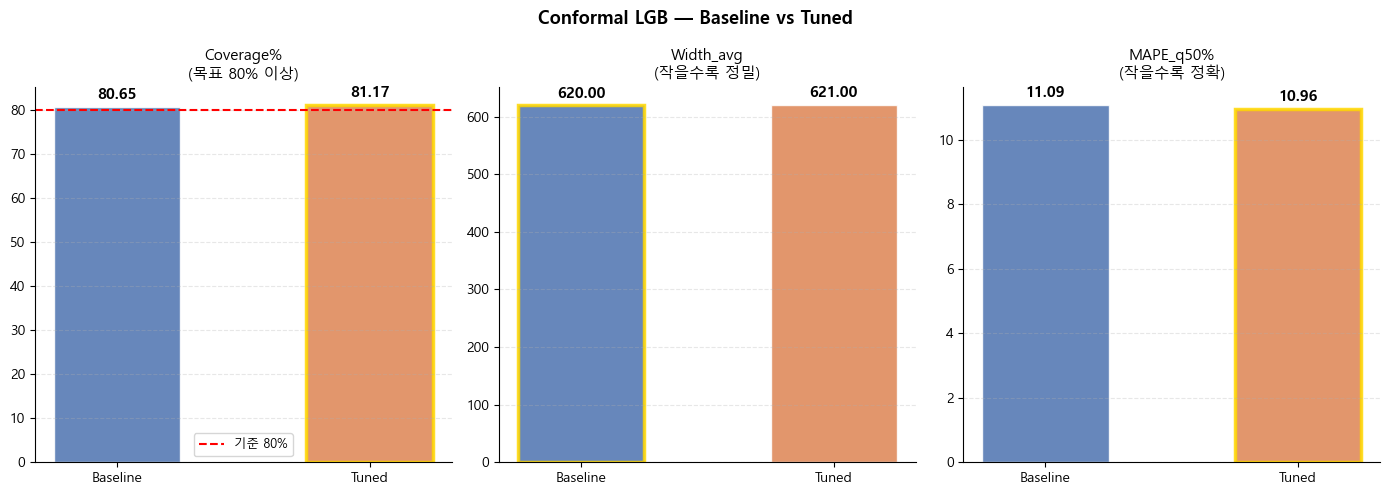

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Conformal LGB — Baseline vs Tuned', fontsize=13, fontweight='bold')

compare_metrics = [
    ('Coverage%',  '목표 80% 이상', 80,   True ),
    ('Width_avg',  '작을수록 정밀', None, False),
    ('MAPE_q50%',  '작을수록 정확', None, False),
]

for ax, (metric, subtitle, threshold, higher_better) in zip(axes, compare_metrics):
    vals   = [BASELINE[metric], TUNED[metric]]
    colors = ['#4C72B0', '#DD8452']
    bars   = ax.bar(['Baseline', 'Tuned'], vals, color=colors,
                    alpha=0.85, edgecolor='white', width=0.5)

    if threshold:
        ax.axhline(threshold, color='red', linestyle='--', lw=1.5,
                   label=f'기준 {threshold}%')
        ax.legend(fontsize=9)

    # 최우수 강조
    best_idx = 0 if (higher_better and vals[0] > vals[1]) or \
                    (not higher_better and vals[0] < vals[1]) else 1
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(f'{metric}\n({subtitle})', fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [14]:
# 랜덤 10건 뽑아서 "판매자 제안 카드" 형식으로 출력
np.random.seed(42)
sample_idx = np.random.choice(len(y_test_raw), 10, replace=False)

print('=' * 62)
print(f'{"#":>2}  {"실제가":>7}  {"하한(Q10)":>9}  {"권장가(Q50)":>11}  {"상한(Q90)":>9}  {"포함":>4}')
print('=' * 62)
for i, idx in enumerate(sample_idx):
    actual  = y_test_raw[idx]
    lo, mid, hi = q10_tuned[idx], q50_tuned[idx], q90_tuned[idx]
    in_rng  = '✅' if lo <= actual <= hi else '❌'
    print(f'{i+1:>2}  {actual:>6.0f}만  {lo:>8.0f}만  {mid:>10.0f}만  {hi:>8.0f}만  {in_rng}')
print('=' * 62)
print(f'\n전체 Test Coverage : {coverage:.1f}%  ({int(in_range.sum()):,}/{len(y_test_raw):,}건)')


 #      실제가    하한(Q10)     권장가(Q50)    상한(Q90)    포함
 1    1930만      1606만        1864만      2209만  ✅
 2    2899만      2320만        2693만      3191만  ✅
 3     930만       887만        1030만      1221만  ✅
 4    2620만      2318만        2690만      3188만  ✅
 5    1519만      1444만        1676만      1986만  ✅
 6     520만       389만         452만       535만  ✅
 7    3350만      2567만        2980만      3531만  ✅
 8    1650만      1630만        1892만      2242만  ✅
 9    2690만      2283만        2651만      3141만  ✅
10    2160만      2074만        2407만      2852만  ✅

전체 Test Coverage : 81.2%  (2,181/2,687건)
